### Subagents
A deep agent can create subagents to delegate work. You can specify custom subagents in the subagents parameter. Subagents are useful for context quarantine (keeping the main agent’s context clean) and for providing specialized instructions.
This page covers synchronous subagents, where the supervisor blocks until the subagent finishes. For long-running tasks, parallel workstreams, or cases where you need mid-flight steering and cancellation, see Async subagents.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

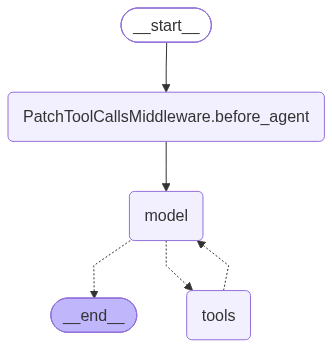

In [2]:
import os
from typing import Literal

from deepagents import create_deep_agent
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,

):
 """Run a web search"""
 return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )


research_subagent={
    "name": "research-agent",
    "description": "Used to research more in depth questions",
    "system_prompt": "You are a great researcher",
    "tools": [internet_search],
    "model": "groq:qwen/qwen3-32b",  # Optional override, defaults to main agent model

}
subagents=[research_subagent]

agent=create_deep_agent(
    model="openai:gpt-5.4",
    subagents=subagents
)
agent


In [3]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "Reserach about LLM Gateways and provide me a detailed summary.",       
          }],
          
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Reserach about LLM Gateways and provide me a detailed summary.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Here’s a detailed summary of **LLM Gateways**—what they are, why teams use them, common capabilities, architectural patterns, tradeoffs, and how to evaluate them.\n\n---\n\n# What is an LLM Gateway?\n\nAn **LLM Gateway** is an infrastructure layer that sits between your application and one or more large language model providers or model runtimes.\n\nInstead of your app calling OpenAI, Anthropic, Google, Azure OpenAI, Bedrock, or self-hosted models directly, it calls the **gateway**. The gateway then handles routing, policy enforcement, observability, cost controls, reliability, and standardization.\n\nYou can think of it as similar to:\n- an **API gateway**, but specialized for AI inference,\n- or a **service mesh/control plane** for mo

### structured Output With Sub Agents

In [4]:
from pydantic import BaseModel, Field
from deepagents import create_deep_agent

class ResearchFindings(BaseModel):
    """Structured findings from a research task."""
    summary: str = Field(description="Summary of findings")
    confidence: float = Field(description="Confidence score from 0 to 1")
    sources: list[str] = Field(description="List of source URLs")

research_subagent = {
    "name": "researcher",
    "description": "Researches topics and returns structured findings",
    "system_prompt": "Research the given topic thoroughly. Return your findings.",
    "tools": [internet_search],
    "response_format": ResearchFindings,
}

agent = create_deep_agent(
    model="openai:gpt-5.4",
    subagents=[research_subagent],
)

result = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Research recent advances in quantum computing"}]}
)

In [5]:
# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research recent advances in quantum computing
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Recent advances in quantum computing span hardware, error correction, algorithms, networking, and industry progress. Here’s a concise overview of the most notable developments through 2024–2025:\n\n## 1. Fault tolerance and error correction\nA major recent focus is moving from noisy intermediate-scale quantum (NISQ) devices toward fault-tolerant quantum computing.\n\n- **Logical qubits improved significantly**: Companies and labs such as Google, IBM, Quantinuum, and academic groups have demonstrated better logical qubit performance using quantum error correction.\n- **Google’s surface-code progress**: Google reported that increasing the size of encoded logical qubits can reduce error rates, a key milestone because earlier systems often got worse as they